# Baseline Model: Logistic Regression

This notebook trains a Logistic Regression model as a baseline for the cancellation prediction task.

## Setup

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    precision_recall_curve, average_precision_score,
    f1_score, fbeta_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')

In [35]:
data_dir = "../data/silver"

X_train = pd.read_parquet(os.path.join(data_dir, "X_train.parquet"))
X_val = pd.read_parquet(os.path.join(data_dir, "X_val.parquet"))
X_test = pd.read_parquet(os.path.join(data_dir, "X_test.parquet"))

y_train = pd.read_parquet(os.path.join(data_dir, "y_train.parquet"))['is_cancelled']
y_val = pd.read_parquet(os.path.join(data_dir, "y_val.parquet"))['is_cancelled']
y_test = pd.read_parquet(os.path.join(data_dir, "y_test.parquet"))['is_cancelled']

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nFeatures: {X_train.columns.tolist()}")
print(f"\nClass distribution (train): {y_train.value_counts(normalize=True).to_dict()}")

X_train shape: (112705, 18)
X_val shape: (25045, 18)
X_test shape: (12250, 18)

Features: ['avg_vtat_imputed', 'vtat_bucket', 'is_high_vtat', 'pickup_encoded', 'drop_encoded', 'vehicle_type_encoded', 'hour', 'dayofweek', 'month', 'is_weekend', 'is_peak_hour', 'is_late_night', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

Class distribution (train): {0.0: 0.6791446697129675, 1.0: 0.3208553302870325}


## Helper Functions

In [36]:
def evaluate_model(y_true, y_pred, y_prob, dataset_name=""):

    f2 = fbeta_score(y_true, y_pred, beta=2)
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    
    print(f"\n{'='*60}")
    print(f"EVALUATION RESULTS - {dataset_name}")
    print(f"{'='*60}")
    
    print(f"\nMetric          | Value   | Target  | Status")
    print(f"-" * 50)
    print(f"F2-Score        | {f2:.4f}  | ≥ 0.68  | {'✅' if f2 >= 0.68 else '❌'}")
    print(f"Recall          | {recall:.4f}  | ≥ 0.70  | {'✅' if recall >= 0.70 else '❌'}")
    print(f"Precision       | {precision:.4f}  | ≥ 0.60  | {'✅' if precision >= 0.60 else '❌'}")
    print(f"F1-Score        | {f1:.4f}  |         |")
    print(f"PR-AUC          | {pr_auc:.4f}  |         |")
    print(f"ROC-AUC         | {roc_auc:.4f}  |         |")
    
    return {
        'f2': f2, 'f1': f1, 'precision': precision, 
        'recall': recall, 'pr_auc': pr_auc, 'roc_auc': roc_auc
    }

In [37]:
def plot_evaluation(y_true, y_pred, y_prob, title=""):

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_title(f'Confusion Matrix - {title}')
    axes[0].set_xticklabels(['Completed', 'Cancelled'])
    axes[0].set_yticklabels(['Completed', 'Cancelled'])
    
    # Precision-Recall Curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    axes[1].plot(recall, precision, 'b-', linewidth=2, label=f'PR-AUC = {pr_auc:.3f}')
    axes[1].axhline(y=0.6, color='r', linestyle='--', label='Precision target (0.6)')
    axes[1].axvline(x=0.7, color='g', linestyle='--', label='Recall target (0.7)')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend(loc='best')
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1])
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    axes[2].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC-AUC = {roc_auc:.3f}')
    axes[2].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[2].set_xlabel('False Positive Rate')
    axes[2].set_ylabel('True Positive Rate')
    axes[2].set_title('ROC Curve')
    axes[2].legend(loc='best')
    
    plt.tight_layout()
    plt.show()

In [38]:
def find_optimal_threshold(y_true, y_prob, beta=2):

    thresholds = np.arange(0.1, 0.9, 0.01)
    best_threshold = 0.5
    best_f_beta = 0
    
    results = []
    for thresh in thresholds:
        y_pred = (y_prob >= thresh).astype(int)
        f_beta = fbeta_score(y_true, y_pred, beta=beta)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        
        results.append({
            'threshold': thresh,
            'f_beta': f_beta,
            'precision': precision,
            'recall': recall
        })
        
        if f_beta > best_f_beta:
            best_f_beta = f_beta
            best_threshold = thresh
    
    return best_threshold, best_f_beta, pd.DataFrame(results)

## Data Preprocessing

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler.")

Features scaled using StandardScaler.


## Train Logistic Regression

In [40]:
model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

model.fit(X_train_scaled, y_train)
print("Model trained.")

Model trained.


In [41]:
y_train_prob = model.predict_proba(X_train_scaled)[:, 1]
y_val_prob = model.predict_proba(X_val_scaled)[:, 1]
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]

y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

## Evaluation with Default Threshold (0.5)


EVALUATION RESULTS - Validation (threshold=0.5)

Metric          | Value   | Target  | Status
--------------------------------------------------
F2-Score        | 0.3296  | ≥ 0.68  | ❌
Recall          | 0.3361  | ≥ 0.70  | ❌
Precision       | 0.3060  | ≥ 0.60  | ❌
F1-Score        | 0.3203  |         |
PR-AUC          | 0.3969  |         |
ROC-AUC         | 0.5429  |         |


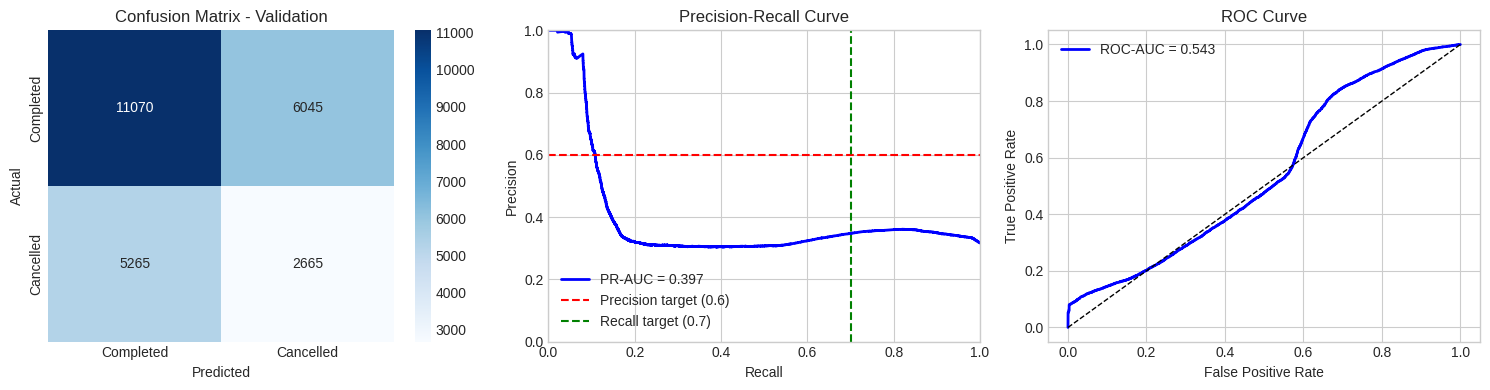

In [42]:
val_metrics = evaluate_model(y_val, y_val_pred, y_val_prob, "Validation (threshold=0.5)")
plot_evaluation(y_val, y_val_pred, y_val_prob, "Validation")

## Threshold Optimization

In [43]:
optimal_threshold, best_f2, threshold_results = find_optimal_threshold(y_val, y_val_prob, beta=2)

print(f"\nOptimal threshold: {optimal_threshold:.2f}")
print(f"Best F2-Score: {best_f2:.4f}")


Optimal threshold: 0.45
Best F2-Score: 0.7053


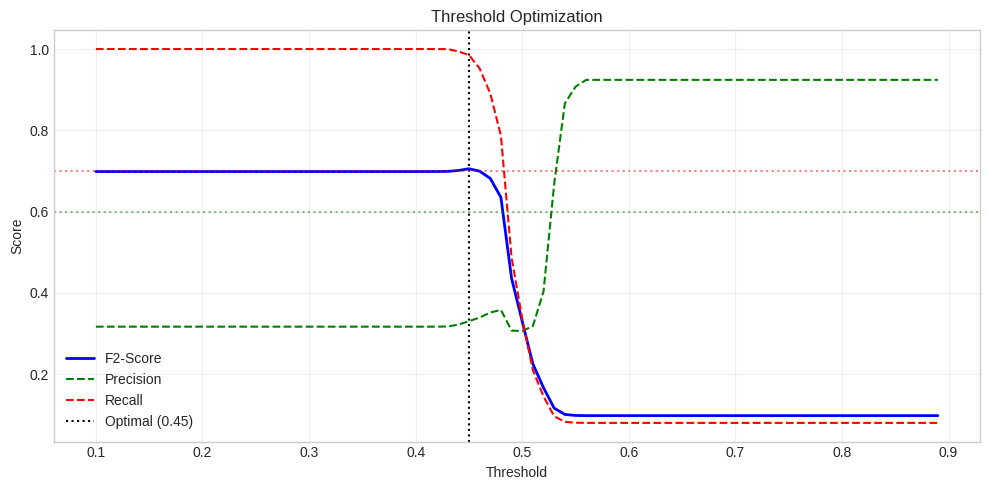

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(threshold_results['threshold'], threshold_results['f_beta'], 'b-', label='F2-Score', linewidth=2)
ax.plot(threshold_results['threshold'], threshold_results['precision'], 'g--', label='Precision')
ax.plot(threshold_results['threshold'], threshold_results['recall'], 'r--', label='Recall')
ax.axvline(x=optimal_threshold, color='k', linestyle=':', label=f'Optimal ({optimal_threshold:.2f})')
ax.axhline(y=0.7, color='r', linestyle=':', alpha=0.5)
ax.axhline(y=0.6, color='g', linestyle=':', alpha=0.5)

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Final Evaluation with Optimal Threshold


EVALUATION RESULTS - Validation (threshold=0.45)

Metric          | Value   | Target  | Status
--------------------------------------------------
F2-Score        | 0.7053  | ≥ 0.68  | ✅
Recall          | 0.9851  | ≥ 0.70  | ✅
Precision       | 0.3302  | ≥ 0.60  | ❌
F1-Score        | 0.4946  |         |
PR-AUC          | 0.3969  |         |
ROC-AUC         | 0.5429  |         |


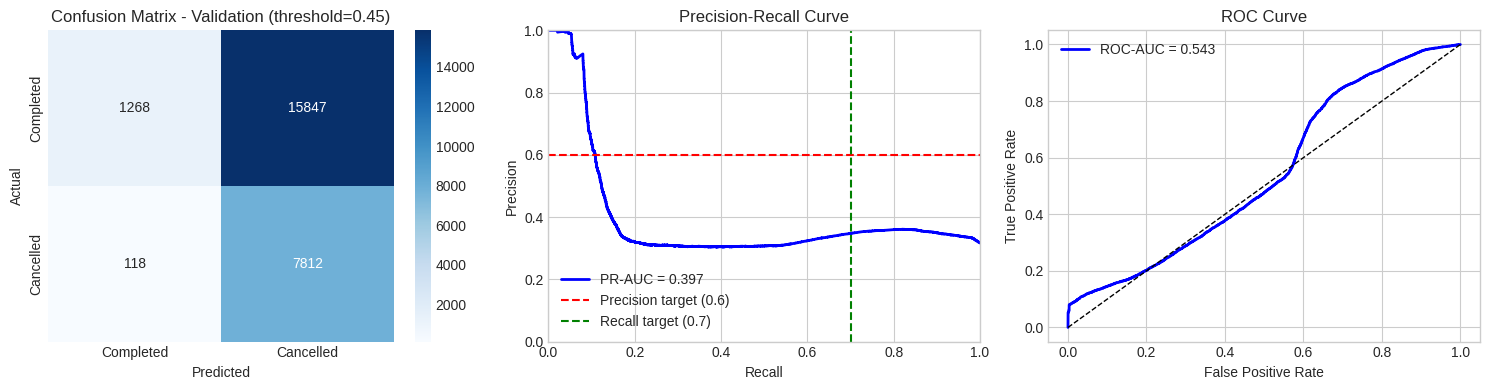

In [45]:
y_val_pred_opt = (y_val_prob >= optimal_threshold).astype(int)
y_test_pred_opt = (y_test_prob >= optimal_threshold).astype(int)

val_metrics_opt = evaluate_model(y_val, y_val_pred_opt, y_val_prob, f"Validation (threshold={optimal_threshold:.2f})")
plot_evaluation(y_val, y_val_pred_opt, y_val_prob, f"Validation (threshold={optimal_threshold:.2f})")


EVALUATION RESULTS - TEST SET (threshold=0.45)

Metric          | Value   | Target  | Status
--------------------------------------------------
F2-Score        | 0.7052  | ≥ 0.68  | ✅
Recall          | 0.9821  | ≥ 0.70  | ✅
Precision       | 0.3315  | ≥ 0.60  | ❌
F1-Score        | 0.4956  |         |
PR-AUC          | 0.3902  |         |
ROC-AUC         | 0.5385  |         |


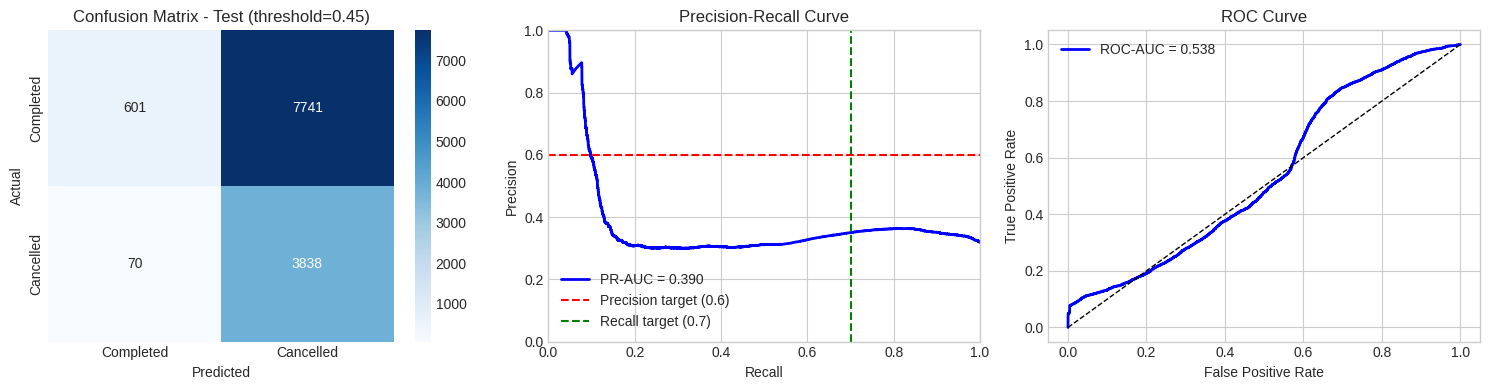

In [46]:
test_metrics = evaluate_model(y_test, y_test_pred_opt, y_test_prob, f"TEST SET (threshold={optimal_threshold:.2f})")
plot_evaluation(y_test, y_test_pred_opt, y_test_prob, f"Test (threshold={optimal_threshold:.2f})")

## Feature Importance

In [47]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print("Feature Importance (by absolute coefficient):")
print(feature_importance)

Feature Importance (by absolute coefficient):
                 feature  coefficient  abs_coefficient
2           is_high_vtat     0.524006         0.524006
0       avg_vtat_imputed    -0.218633         0.218633
1            vtat_bucket     0.156979         0.156979
9             is_weekend    -0.017316         0.017316
3         pickup_encoded     0.015462         0.015462
7              dayofweek     0.014824         0.014824
4           drop_encoded     0.014511         0.014511
15               dow_cos     0.011718         0.011718
8                  month     0.007396         0.007396
16             month_sin    -0.007037         0.007037
17             month_cos     0.004380         0.004380
11         is_late_night     0.004310         0.004310
6                   hour    -0.003750         0.003750
13              hour_cos     0.003612         0.003612
12              hour_sin    -0.003520         0.003520
10          is_peak_hour    -0.002994         0.002994
14               do

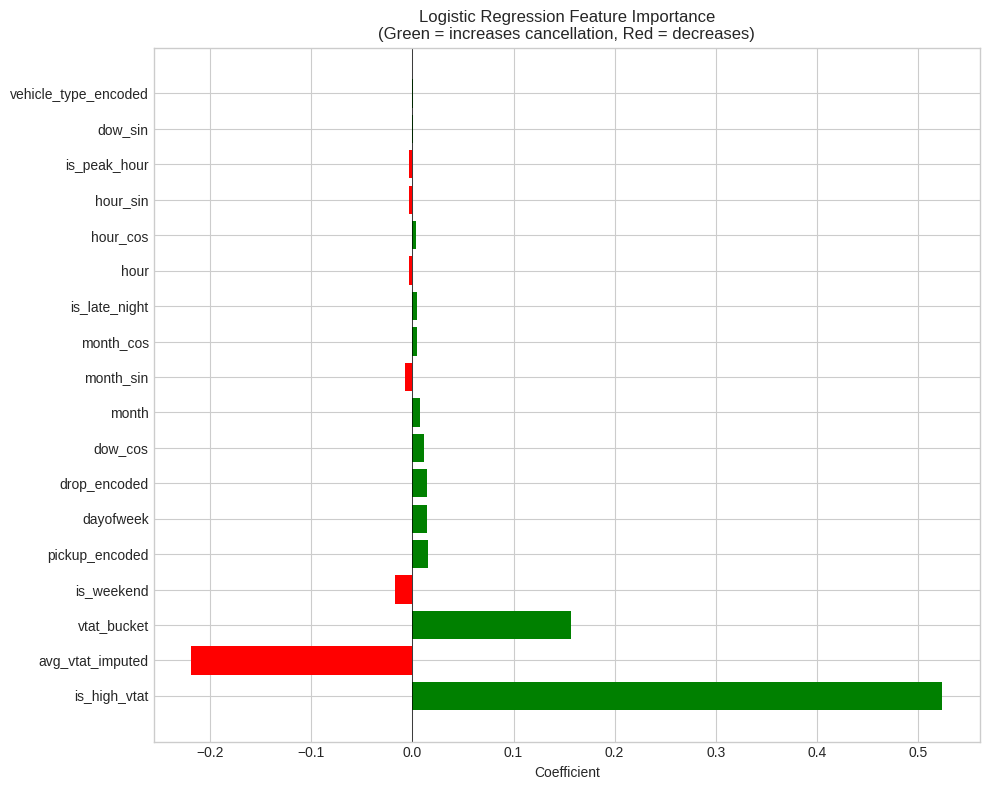

In [48]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['green' if c > 0 else 'red' for c in feature_importance['coefficient']]
ax.barh(feature_importance['feature'], feature_importance['coefficient'], color=colors)
ax.set_xlabel('Coefficient')
ax.set_title('Logistic Regression Feature Importance\n(Green = increases cancellation, Red = decreases)')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

## Save Model

In [49]:
model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)

model_artifacts = {
    'model': model,
    'scaler': scaler,
    'optimal_threshold': optimal_threshold,
    'feature_names': X_train.columns.tolist(),
    'test_metrics': test_metrics
}

with open(os.path.join(model_dir, "logistic_regression.pkl"), 'wb') as f:
    pickle.dump(model_artifacts, f)

print(f"Model saved to {model_dir}/logistic_regression.pkl")

Model saved to ../models/logistic_regression.pkl
